In [1]:
from pathlib import Path
from PIL import Image
import numpy as np
import json
import random
import shutil

ROOT = Path.cwd()

if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

LOVEDA_ROOT = ROOT

print("Project root:", ROOT)

for folder in ["Train", "Val", "Test"]:
    print(
        f"{folder}:",
        (LOVEDA_ROOT / folder).exists()
    )

Project root: c:\Users\shreyas\Documents\UrbanWatch
Train: True
Val: True
Test: True


In [2]:
from collections import Counter

splits = {
    "train": LOVEDA_ROOT / "Train",
    "val": LOVEDA_ROOT / "Val",
}

for split, split_dir in splits.items():

    counter = Counter()
    total_pixels = 0

    print("\n" + "=" * 70)
    print(split.upper())
    print("=" * 70)

    for region in ["Rural", "Urban"]:

        mask_dir = (
            split_dir
            / region
            / "masks_png"
        )

        mask_files = sorted(
            mask_dir.glob("*.png")
        )

        print(
            f"{region}: {len(mask_files)} masks"
        )

        for mask_path in mask_files:

            mask = np.array(
                Image.open(mask_path)
            )

            values, counts = np.unique(
                mask,
                return_counts=True
            )

            for value, count in zip(
                values,
                counts
            ):
                counter[int(value)] += int(count)
                total_pixels += int(count)

    print("\nClass distribution:")

    for cls in sorted(counter):
        percentage = (
            counter[cls]
            / total_pixels
            * 100
        )

        print(
            f"Class {cls}: "
            f"{counter[cls]:,} pixels "
            f"({percentage:.2f}%)"
        )


TRAIN
Rural: 1366 masks
Urban: 1156 masks

Class distribution:
Class 0: 99,632,059 pixels (3.77%)
Class 1: 910,708,330 pixels (34.44%)
Class 2: 281,493,525 pixels (10.64%)
Class 3: 134,119,839 pixels (5.07%)
Class 4: 162,729,743 pixels (6.15%)
Class 5: 132,748,857 pixels (5.02%)
Class 6: 409,074,984 pixels (15.47%)
Class 7: 514,001,335 pixels (19.44%)

VAL
Rural: 992 masks
Urban: 677 masks

Class distribution:
Class 0: 45,777,073 pixels (2.62%)
Class 1: 615,250,682 pixels (35.16%)
Class 2: 122,805,791 pixels (7.02%)
Class 3: 79,590,500 pixels (4.55%)
Class 4: 199,567,816 pixels (11.40%)
Class 5: 74,383,133 pixels (4.25%)
Class 6: 125,615,647 pixels (7.18%)
Class 7: 487,082,702 pixels (27.83%)


In [3]:
for split in ["Train", "Val"]:

    split_dir = LOVEDA_ROOT / split

    print("\n" + "=" * 70)
    print(split.upper())
    print("=" * 70)

    for region in ["Rural", "Urban"]:

        image_dir = (
            split_dir
            / region
            / "images_png"
        )

        mask_dir = (
            split_dir
            / region
            / "masks_png"
        )

        image_files = {
            p.name
            for p in image_dir.glob("*.png")
        }

        mask_files = {
            p.name
            for p in mask_dir.glob("*.png")
        }

        common = image_files & mask_files

        print(
            f"{region}: "
            f"images={len(image_files)}, "
            f"masks={len(mask_files)}, "
            f"pairs={len(common)}"
        )

        print(
            "Missing masks:",
            len(image_files - mask_files)
        )

        print(
            "Missing images:",
            len(mask_files - image_files)
        )


TRAIN
Rural: images=1366, masks=1366, pairs=1366
Missing masks: 0
Missing images: 0
Urban: images=1156, masks=1156, pairs=1156
Missing masks: 0
Missing images: 0

VAL
Rural: images=992, masks=992, pairs=992
Missing masks: 0
Missing images: 0
Urban: images=677, masks=677, pairs=677
Missing masks: 0
Missing images: 0


In [4]:
for split in ["Train", "Val"]:

    split_dir = LOVEDA_ROOT / split

    print("\n" + "=" * 70)
    print(split.upper(), "IMAGE/MASK VALIDATION")
    print("=" * 70)

    for region in ["Rural", "Urban"]:

        image_dir = (
            split_dir
            / region
            / "images_png"
        )

        mask_dir = (
            split_dir
            / region
            / "masks_png"
        )

        invalid_images = 0
        invalid_masks = 0

        class_values = set()

        for image_path in image_dir.glob("*.png"):

            image = Image.open(
                image_path
            )

            if image.size != (1024, 1024):
                invalid_images += 1

        for mask_path in mask_dir.glob("*.png"):

            mask = np.array(
                Image.open(mask_path)
            )

            if mask.shape != (1024, 1024):
                invalid_masks += 1

            class_values.update(
                np.unique(mask).tolist()
            )

        print(f"\n{region}")

        print(
            "Invalid images:",
            invalid_images
        )

        print(
            "Invalid masks:",
            invalid_masks
        )

        print(
            "Classes:",
            sorted(class_values)
        )


TRAIN IMAGE/MASK VALIDATION

Rural
Invalid images: 0
Invalid masks: 0
Classes: [0, 1, 2, 3, 4, 5, 6, 7]

Urban
Invalid images: 0
Invalid masks: 0
Classes: [0, 1, 2, 3, 4, 5, 6, 7]

VAL IMAGE/MASK VALIDATION

Rural
Invalid images: 0
Invalid masks: 0
Classes: [0, 1, 2, 3, 4, 5, 6, 7]

Urban
Invalid images: 0
Invalid masks: 0
Classes: [0, 1, 2, 3, 4, 5, 6, 7]


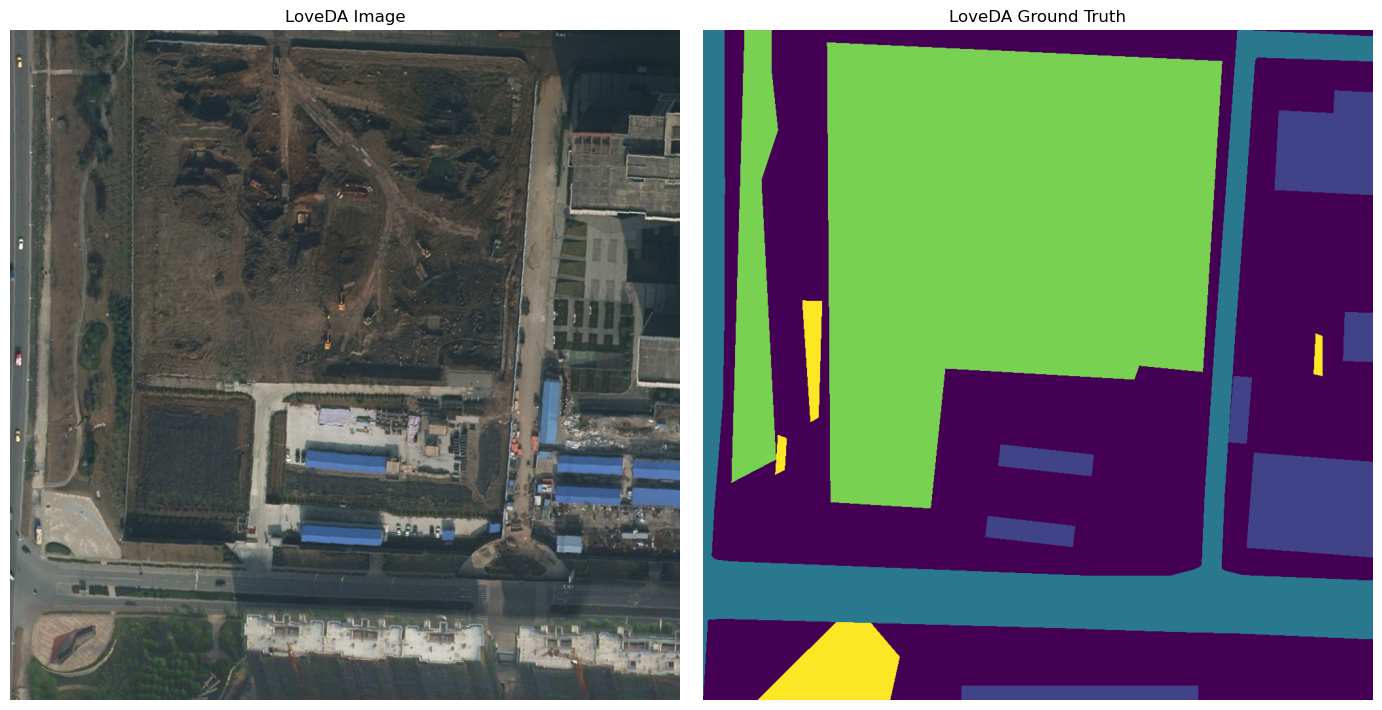

Image shape: (1024, 1024, 3)
Mask shape: (1024, 1024)
Mask classes: [1 2 3 5 6]


In [5]:
import matplotlib.pyplot as plt

image_path = (
    LOVEDA_ROOT
    / "Train"
    / "Urban"
    / "images_png"
    / "1366.png"
)

mask_path = (
    LOVEDA_ROOT
    / "Train"
    / "Urban"
    / "masks_png"
    / "1366.png"
)

image = np.array(
    Image.open(image_path)
)

mask = np.array(
    Image.open(mask_path)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

axes[0].imshow(image)
axes[0].set_title("LoveDA Image")
axes[0].axis("off")

axes[1].imshow(mask)
axes[1].set_title("LoveDA Ground Truth")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print(
    "Mask classes:",
    np.unique(mask)
)

In [6]:
PROCESSED_ROOT = (
    ROOT
    / "data"
    / "loveda"
)

for split in ["train", "val"]:

    for folder in [
        "images",
        "masks"
    ]:

        (
            PROCESSED_ROOT
            / split
            / folder
        ).mkdir(
            parents=True,
            exist_ok=True
        )

print(
    "Created:",
    PROCESSED_ROOT
)

Created: c:\Users\shreyas\Documents\UrbanWatch\data\loveda


In [7]:
CROP_SIZE = 512

def create_crops(
    image,
    mask
):

    crops = []

    positions = [
        (0, 0),
        (0, CROP_SIZE),
        (CROP_SIZE, 0),
        (CROP_SIZE, CROP_SIZE)
    ]

    for top, left in positions:

        image_crop = image[
            top:top + CROP_SIZE,
            left:left + CROP_SIZE
        ]

        mask_crop = mask[
            top:top + CROP_SIZE,
            left:left + CROP_SIZE
        ]

        crops.append(
            (
                image_crop,
                mask_crop
            )
        )

    return crops